# G1 Academy Bonus - Task 4: robot-state observation (dictionary-based get_* interface)

## Introduction
This task builds the dictionary-based state readers described in `notes.txt` section 2: `get_lowstate`, `get_odommodestate`, `get_battery`, `get_slam_info`, `get_occupancygrid`, `get_rgbd`, and `get_services`. Each one wraps a native subscriber or SDK client and normalizes the result into a plain dictionary, so higher-level tasks never touch raw DDS message layouts directly. This notebook is self-contained: it repeats the `ensure_channel_factory`/`Latest` helpers from Task 2 so it can run on its own.

In [12]:
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from unitree_sdk2py.core.channel import ChannelFactoryInitialize, ChannelSubscriber
from unitree_sdk2py.idl.unitree_hg.msg.dds_ import LowState_

_factory_config = None
def ensure_channel_factory(domain_id, interface):
    global _factory_config
    config = (int(domain_id), str(interface))
    if _factory_config is None:
        ChannelFactoryInitialize(*config)
        _factory_config = config
    elif _factory_config != config:
        raise RuntimeError(f"ChannelFactory already initialized as {_factory_config}; restart kernel for {config}.")
    return _factory_config

ensure_channel_factory(0, "eth0")

class Latest:
    def __init__(self, topic, message_type, queue_len=10):
        self.topic = str(topic)
        self.message = None
        self.timestamp = 0.0
        self.subscriber = ChannelSubscriber(topic, message_type)
        self.subscriber.Init(self._callback, queue_len)
    def _callback(self, message):
        self.message = message
        self.timestamp = time.time()
    def fresh(self, max_age_s=0.5):
        return self.message is not None and time.time() - self.timestamp <= max_age_s

def wait_for_latest(latest, timeout_s=3.0, max_age_s=1.0):
    deadline = time.time() + max(0.0, float(timeout_s))
    while time.time() < deadline:
        if latest.fresh(max_age_s=max_age_s):
            return latest.message
        time.sleep(0.05)
    return latest.message if latest.message is not None else None

def status_frame(name, value=None):
    return pd.DataFrame([{"name": name, "value": value, "status": "no data received"}])

def normalize_record(record):
    try:
        normalizer = pd.json_normalize
    except AttributeError:
        try:
            from pandas.io.json import json_normalize as normalizer
        except ImportError:
            normalizer = None
    if normalizer is not None:
        return normalizer(record)
    return pd.DataFrame([record])

def display_record(record, name="result"):
    if record is None:
        display(status_frame(name))
    elif isinstance(record, list):
        display(pd.DataFrame(record))
    elif isinstance(record, dict):
        display(normalize_record(record))
    else:
        display(pd.DataFrame([{"name": name, "value": record}]))


## Task 1 - `get_lowstate()`
Joint positions/velocities/torques and IMU fields, read from the cached `rt/lowstate` message.

In [13]:
lowstate_sub = Latest("rt/lowstate", LowState_)

def get_lowstate(timeout_s=3.0):
    msg = wait_for_latest(lowstate_sub, timeout_s=timeout_s, max_age_s=1.0)
    if msg is None:
        return None
    motors = list(msg.motor_state)
    imu = msg.imu_state
    return {
        "timestamp": lowstate_sub.timestamp,
        "joint_positions": [float(m.q) for m in motors],
        "joint_velocities": [float(m.dq) for m in motors],
        "joint_torques": [float(m.tau_est) for m in motors],
        "imu": {
            "rpy": [float(imu.rpy[i]) for i in range(3)],
            "gyro": [float(imu.gyroscope[i]) for i in range(3)],
            "acc": [float(imu.accelerometer[i]) for i in range(3)],
        },
    }

def display_lowstate(data):
    if data is None:
        display(status_frame("rt/lowstate"))
        return
    display(pd.DataFrame([{"timestamp": data["timestamp"], "joint_count": len(data["joint_positions"])}]))
    display(pd.DataFrame(data["imu"], index=("roll/x", "pitch/y", "yaw/z")))
    display(pd.DataFrame({
        "joint": list(range(len(data["joint_positions"]))),
        "q": data["joint_positions"],
        "dq": data["joint_velocities"],
        "tau_est": data["joint_torques"],
    }))

lowstate = get_lowstate()
display_lowstate(lowstate)


,timestamp,joint_count
0,1.788175e+09,35


,rpy,gyro,acc
roll/x,0.003093,-0.005326,-0.244209
pitch/y,0.035823,-0.083091,-0.084396
yaw/z,0.361952,0.021305,9.908403


,joint,q,dq,tau_est
0,0,-0.325869,0.161443,0.615234
1,1,-0.021714,-0.017453,1.230469
2,2,0.019070,0.005142,-0.950817
3,3,0.603928,-0.017453,-9.492188
4,4,-0.326996,-0.005803,7.915642
5,5,0.021393,0.002742,-1.290632
6,6,-0.340620,0.159261,1.933594
7,7,0.037642,0.001091,-3.339844
8,8,-0.025793,0.020570,1.901634
9,9,0.634966,-0.004363,-9.580078


## Task 2 - `get_odommodestate()`
Field names on `SportModeState_` vary a little across SDK/firmware versions, so read defensively with `getattr` fallbacks instead of assuming one exact attribute name - the same defensive pattern `sdk_wrapper` uses internally.

In [15]:
from unitree_sdk2py.idl.unitree_go.msg.dds_ import SportModeState_

odom_sub = Latest("rt/odommodestate", SportModeState_)

def _first_attr(obj, names, default=None):
    for name in names:
        if hasattr(obj, name):
            return getattr(obj, name)
    return default

def get_odommodestate(timeout_s=3.0):
    msg = wait_for_latest(odom_sub, timeout_s=timeout_s, max_age_s=1.0)
    if msg is None:
        return None
    position = _first_attr(msg, ("position", "pos", "position_w"))
    velocity = _first_attr(msg, ("velocity", "vel"))
    gait = _first_attr(msg, ("gait_type", "gaitType", "gait"))
    row = {
        "timestamp": odom_sub.timestamp,
        "mode": None if getattr(msg, "mode", None) is None else int(msg.mode),
        "gait_type": None if gait is None else int(gait),
    }
    if position is not None:
        row.update({f"position_{axis}": float(value) for axis, value in zip("xyz", position)})
    if velocity is not None:
        row.update({f"velocity_{axis}": float(value) for axis, value in zip("xyz", velocity)})
    return row

display_record(get_odommodestate(), "rt/odommodestate")


,timestamp,mode,gait_type,position_x,position_y,position_z,velocity_x,velocity_y,velocity_z
0,1.788175e+09,0,0,6.37412,0.112625,0.70831,0.019222,0.000839,-0.012257


## Task 3 - `get_battery()`
Battery data can arrive on a dedicated `BmsState_` topic (name and message module vary by platform), or embedded inside `rt/lowstate`. Try the dedicated topics first, fall back to `rt/lowstate` fields.

In [16]:
import importlib

def _bms_types():
    types = []
    for module_name in ("unitree_sdk2py.idl.unitree_hg.msg.dds_", "unitree_sdk2py.idl.unitree_go.msg.dds_"):
        module = importlib.import_module(module_name)
        if hasattr(module, "BmsState_"):
            types.append(module.BmsState_)
    return types

BMS_TOPICS = ["rt/lf/bmsstate", "rt/lf/agvbmsstate", "rt/bmsstate", "rt/agvbmsstate"]
bms_subs = [(topic, Latest(topic, msg_type)) for topic in BMS_TOPICS for msg_type in _bms_types()]

def get_battery(timeout_s=3.0):
    deadline = time.time() + max(0.0, float(timeout_s))
    while time.time() < deadline:
        for topic, sub in bms_subs:
            if sub.fresh(max_age_s=3.0):
                msg = sub.message
                return {"source": topic, "timestamp": sub.timestamp, "soc": int(msg.soc), "current": int(msg.current), "cycle": int(msg.cycle)}
        if lowstate_sub.fresh(max_age_s=3.0):
            break
        time.sleep(0.05)
    msg = lowstate_sub.message
    if msg is None:
        return None
    return {
        "source": "rt/lowstate",
        "timestamp": lowstate_sub.timestamp,
        "power_v": None if getattr(msg, "power_v", None) is None else float(msg.power_v),
        "power_a": None if getattr(msg, "power_a", None) is None else float(msg.power_a),
    }

display_record(get_battery(), "battery")

,source,timestamp,soc,current,cycle
0,rt/lf/bmsstate,1.788175e+09,16,-2842,38


## Task 4 - `get_slam_info()`
SLAM status arrives as a JSON-in-`String_` payload on `rt/slam_info`, with `rt/slam_key_info` as a fallback.

In [18]:
from unitree_sdk2py.idl.std_msgs.msg.dds_ import String_

slam_info_sub = Latest("rt/slam_info", String_)
slam_key_sub = Latest("rt/slam_key_info", String_)

def get_slam_info(timeout_s=3.0):
    msg = wait_for_latest(slam_info_sub, timeout_s=timeout_s, max_age_s=3.0)
    if msg is not None:
        return msg.data
    msg = wait_for_latest(slam_key_sub, timeout_s=timeout_s, max_age_s=3.0)
    if msg is not None:
        return msg.data
    return None

def display_slam_info(raw):
    if raw is None:
        display(status_frame("rt/slam_info / rt/slam_key_info"))
        return
    try:
        payload = json.loads(raw)
    except Exception:
        display(pd.DataFrame([{"raw": raw}]))
        return
    display(normalize_record(payload))

display_slam_info(get_slam_info())


,type,sec,nanosec,errorCode,info,data.currentPose.x,data.currentPose.y,data.currentPose.z,data.currentPose.q_w,data.currentPose.q_x,data.currentPose.q_y,data.currentPose.q_z,data.pcdName,data.address
0,pos_info,1788174635,120931072,0,,-0.00625,0.083414,0.048832,0.98216,0.00235,0.045232,0.182511,test,/home/unitree/test.pcd


## Task 5 - `get_occupancygrid()` / lidar map plot
The deployed map-like grid available on this robot is `rt/utlidar/map_state` (`HeightMap_`). Treat it as an occupancy-style grid for observation: wait for a fresh message, reshape the flat data into a 2-D array, display the metadata as a DataFrame, and plot the grid with Matplotlib.

In [20]:
from unitree_sdk2py.idl.unitree_go.msg.dds_ import HeightMap_

occupancygrid_sub = Latest("rt/utlidar/map_state", HeightMap_, queue_len=5)

def get_occupancygrid(timeout_s=3.0):
    msg = wait_for_latest(occupancygrid_sub, timeout_s=timeout_s, max_age_s=3.0)
    if msg is None:
        return None
    width = int(msg.width)
    height = int(msg.height)
    resolution = float(msg.resolution)
    data = np.asarray(list(msg.data), dtype=float)
    if width <= 0 or height <= 0 or data.size != width * height:
        raise ValueError(f"invalid map dimensions: width={width}, height={height}, data={data.size}")
    return {
        "timestamp": occupancygrid_sub.timestamp,
        "topic": occupancygrid_sub.topic,
        "width": width,
        "height": height,
        "resolution": resolution,
        "grid": data.reshape((height, width)),
    }

def display_occupancygrid(grid_info):
    if grid_info is None:
        #display(status_frame("rt/utlidar/map_state"))
        display(status_frame("/utlidar/cloud_livox_mid360"))
        return
    display(pd.DataFrame([{k: v for k, v in grid_info.items() if k != "grid"}]))
    plt.figure(figsize=(7, 6))
    plt.imshow(grid_info["grid"], origin="lower", cmap="viridis")
    plt.colorbar(label="map value")
    plt.title(grid_info["topic"])
    plt.xlabel("cell x")
    plt.ylabel("cell y")
    plt.show()

display_occupancygrid(get_occupancygrid())


,name,value,status
0,/utlidar/cloud_livox_mid360,None,no data received


## Task 6 - `get_rgbd()`
RGB-D frames come from `rgbd_server_service` (see `realsense_rgbd_zmq_stream.py`), a ZMQ PUB socket sending `[rgb_jpeg, depth_png, depth_scale]` multipart frames. Connect as SUB, take the newest frame, and decode the pieces lazily (callers decide whether they need the depth channel).

,timestamp,endpoint,rgb_shape,depth_shape,depth_scale
0,1.788175e+09,tcp://127.0.0.1:5555,"(480, 640, 3)","(480, 640)",0.001


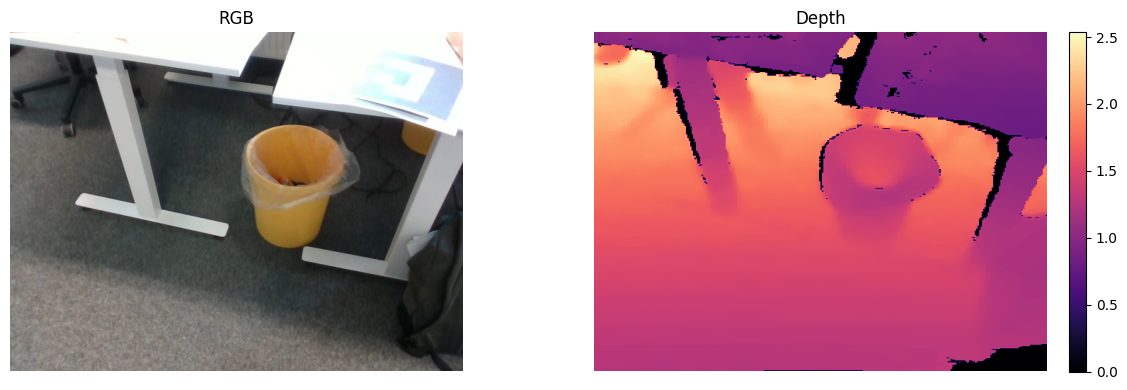

In [21]:
import os
import struct

def rgbd_endpoints():
    env_endpoint = os.environ.get("G1_RGBD_ENDPOINT")
    host = os.environ.get("G1_RGBD_HOST", "10.34.0.83")
    candidates = [env_endpoint, f"tcp://{host}:5555", "tcp://127.0.0.1:5555", "tcp://localhost:5555"]
    return tuple(endpoint for endpoint in candidates if endpoint)

def get_rgbd(endpoints=None):
    endpoints = rgbd_endpoints() if endpoints is None else tuple(endpoints)
    import zmq
    ctx = zmq.Context.instance()
    last_error = None
    for endpoint in endpoints:
        sock = ctx.socket(zmq.SUB)
        sock.setsockopt(zmq.SUBSCRIBE, b"")
        sock.setsockopt(zmq.RCVTIMEO, 3000)
        try:
            sock.connect(endpoint)
            parts = sock.recv_multipart()
            if len(parts) < 3:
                continue
            scale = struct.unpack("f", parts[2])[0] if parts[2] != b"0" and len(parts[2]) == 4 else None
            return {
                "timestamp": time.time(),
                "endpoint": endpoint,
                "rgb_jpeg": bytes(parts[0]),
                "depth_png": None if parts[1] == b"0" else bytes(parts[1]),
                "depth_scale": scale,
            }
        except Exception as exc:
            last_error = exc
        finally:
            sock.close(0)
    if last_error is not None:
        raise last_error
    return None

def _decode_image_bytes(data, *, color=False):
    try:
        import cv2
        arr = np.frombuffer(data, dtype=np.uint8)
        flag = cv2.IMREAD_COLOR if color else cv2.IMREAD_UNCHANGED
        image = cv2.imdecode(arr, flag)
        if image is None:
            raise ValueError("cv2.imdecode returned None")
        if color:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        return image
    except Exception:
        from io import BytesIO
        from PIL import Image
        return np.asarray(Image.open(BytesIO(data)))

def display_rgbd(frame):
    if frame is None:
        display(status_frame("rgbd"))
        return
    rgb = _decode_image_bytes(frame["rgb_jpeg"], color=True)
    depth = None if frame["depth_png"] is None else _decode_image_bytes(frame["depth_png"], color=False)
    display(pd.DataFrame([{
        "timestamp": frame["timestamp"],
        "endpoint": frame["endpoint"],
        "rgb_shape": tuple(rgb.shape),
        "depth_shape": None if depth is None else tuple(depth.shape),
        "depth_scale": frame["depth_scale"],
    }]))
    cols = 1 if depth is None else 2
    fig, axes = plt.subplots(1, cols, figsize=(6 * cols, 4))
    if cols == 1:
        axes = [axes]
    axes[0].imshow(rgb)
    axes[0].set_title("RGB")
    axes[0].axis("off")
    if depth is not None:
        depth_plot = depth.astype("float32") * float(frame["depth_scale"] or 1.0)
        im = axes[1].imshow(depth_plot, cmap="magma")
        axes[1].set_title("Depth")
        axes[1].axis("off")
        fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

frame = get_rgbd()
display_rgbd(frame)


## Task 7 - `get_services()`
`RobotStateClient.ServiceList()` returns every registered service's name/status/protect flag; annotate the known ones with the documented description catalog.

In [22]:
try:
    from unitree_sdk2py.b2.robot_state.robot_state_client import RobotStateClient
except ImportError:
    from unitree_sdk2py.go2.robot_state.robot_state_client import RobotStateClient

robot_state_client = RobotStateClient()
robot_state_client.SetTimeout(5.0)
robot_state_client.Init()

SERVICE_CATALOG = {
    "ai_sport": "Main Motion Control Service", "basic_service": "Basic Service",
    "g1_arm_example": "Upper Limb Motion Service", "vui_service": "Audio and Lighting Control Service",
    "unitree_slam": "Navigation Service",
}

def get_services():
    code, service_states = robot_state_client.ServiceList()
    if int(code) != 0:
        raise RuntimeError(f"ServiceList failed: {code}")
    return [
        {"name": s.name, "description": SERVICE_CATALOG.get(s.name, ""), "status": int(s.status), "protected": bool(s.protect)}
        for s in service_states
    ]

display_record(get_services(), "services")

,name,description,status,protected
0,ai_sport,Main Motion Control Service,0,False
1,audio_player_service,,0,False
2,auto_test_arm,,1,False
3,auto_test_low,,1,False
4,bashrunner,,0,False
5,basic_service,Basic Service,0,True
6,battery_guard,,0,False
7,chat_go,,0,False
8,dex3_service_l,,0,False
9,dex3_service_r,,0,False


### Safety
Run no command cell until the subscriber state is fresh, controller ownership is known, the space is clear, and a damp path is available. Code is not invoked automatically.